# Smart School Project – ECAM 2026
## Prédiction d'échec & Correction automatique par OCR

> **Dataset 1** : `train.csv` – 630 000 étudiants, 14 features  
> **Dataset 2** : images EMNIST 28×28px – 62 classes (chiffres + lettres)

---

## 0. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import struct
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']
sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.1)

print('Imports OK')

Imports OK


---
# PARTIE 1 : Prédiction d'échec aux examens
---

## 1.1 Chargement et exploration du dataset

In [2]:
# Adapter le chemin selon votre environnement
DATA_PATH = 'train.csv'  # ou chemin complet

df = pd.read_csv('student_dataset/student_failure/train.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (630000, 15)


,id,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
0,0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94


In [3]:
print('Types et valeurs manquantes:')
print(df.dtypes)
print()
print(df.isnull().sum())

Types et valeurs manquantes:
id                            int64
age                           int64
genre                        object
diplôme                      object
heures_etude                float64
assiduité_classe            float64
accès_internet               object
heures_sommeil              float64
qualité_sommeil              object
méthode_etude                object
évaluation_établissement     object
difficulté_examen            object
score_examen                float64
heures_fête                   int64
taille_etudiant             float64
dtype: object

id                              0
age                             0
genre                           0
diplôme                         0
heures_etude                18900
assiduité_classe                0
accès_internet              63000
heures_sommeil                  0
qualité_sommeil                 0
méthode_etude               44100
évaluation_établissement        0
difficulté_examen               0
score_ex

In [4]:
print(df.describe())

                  id            age   heures_etude  assiduité_classe  \
count  630000.000000  630000.000000  611100.000000     630000.000000   
mean   314999.500000      20.545821       4.002779         71.987261   
std    181865.479132       2.260238       2.359388         17.430098   
min         0.000000      17.000000       0.080000         40.600000   
25%    157499.750000      19.000000       1.980000         57.000000   
50%    314999.500000      21.000000       4.010000         72.600000   
75%    472499.250000      23.000000       6.050000         87.200000   
max    629999.000000      24.000000       7.910000         99.400000   

       heures_sommeil   score_examen    heures_fête  taille_etudiant  
count   630000.000000  630000.000000  630000.000000    630000.000000  
mean         7.072758      63.406789       4.000514         1.754836  
std          1.744811      18.950840       2.000382         0.131891  
min          4.100000      12.600000       0.000000         1.48000

## 1.2 Définition de la variable cible

In [5]:
# Score < 50 => échec
df['echec'] = (df['score_examen'] < 50).astype(int)

print(f"Taux d'échec global : {df['echec'].mean():.2%}")
print(df['echec'].value_counts())

Taux d'échec global : 25.57%
echec
0    468917
1    161083
Name: count, dtype: int64


## 1.3 Analyse exploratoire des données (EDA)

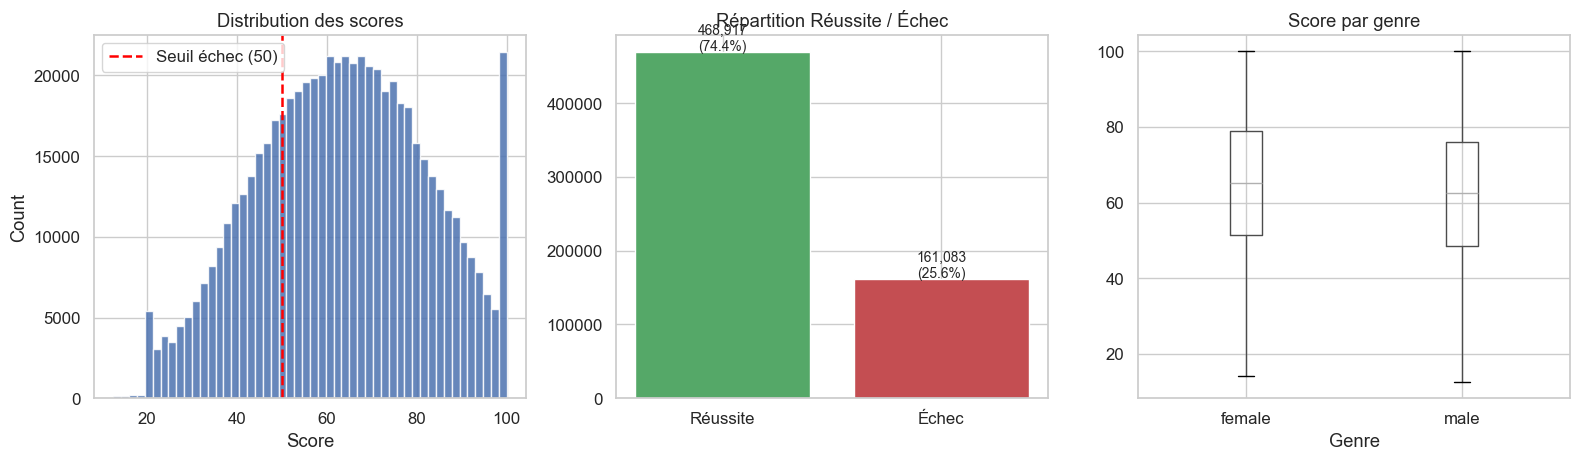

In [6]:
# --- Distribution du score et variable cible ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution du score et variable cible', fontsize=14, fontweight='bold')

axes[0].hist(df['score_examen'], bins=50, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(50, color='red', linestyle='--', linewidth=1.8, label='Seuil échec (50)')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Count')
axes[0].set_title('Distribution des scores'); axes[0].legend()

vals = df['echec'].value_counts()
axes[1].bar(['Réussite', 'Échec'], [vals[0], vals[1]], color=[PALETTE[2], PALETTE[3]])
for i, v in enumerate([vals[0], vals[1]]):
    axes[1].text(i, v + 2000, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=10)
axes[1].set_title('Répartition Réussite / Échec')

df.boxplot(column='score_examen', by='genre', ax=axes[2])
axes[2].set_title('Score par genre'); axes[2].set_xlabel('Genre')
plt.suptitle('')
plt.tight_layout()
plt.show()

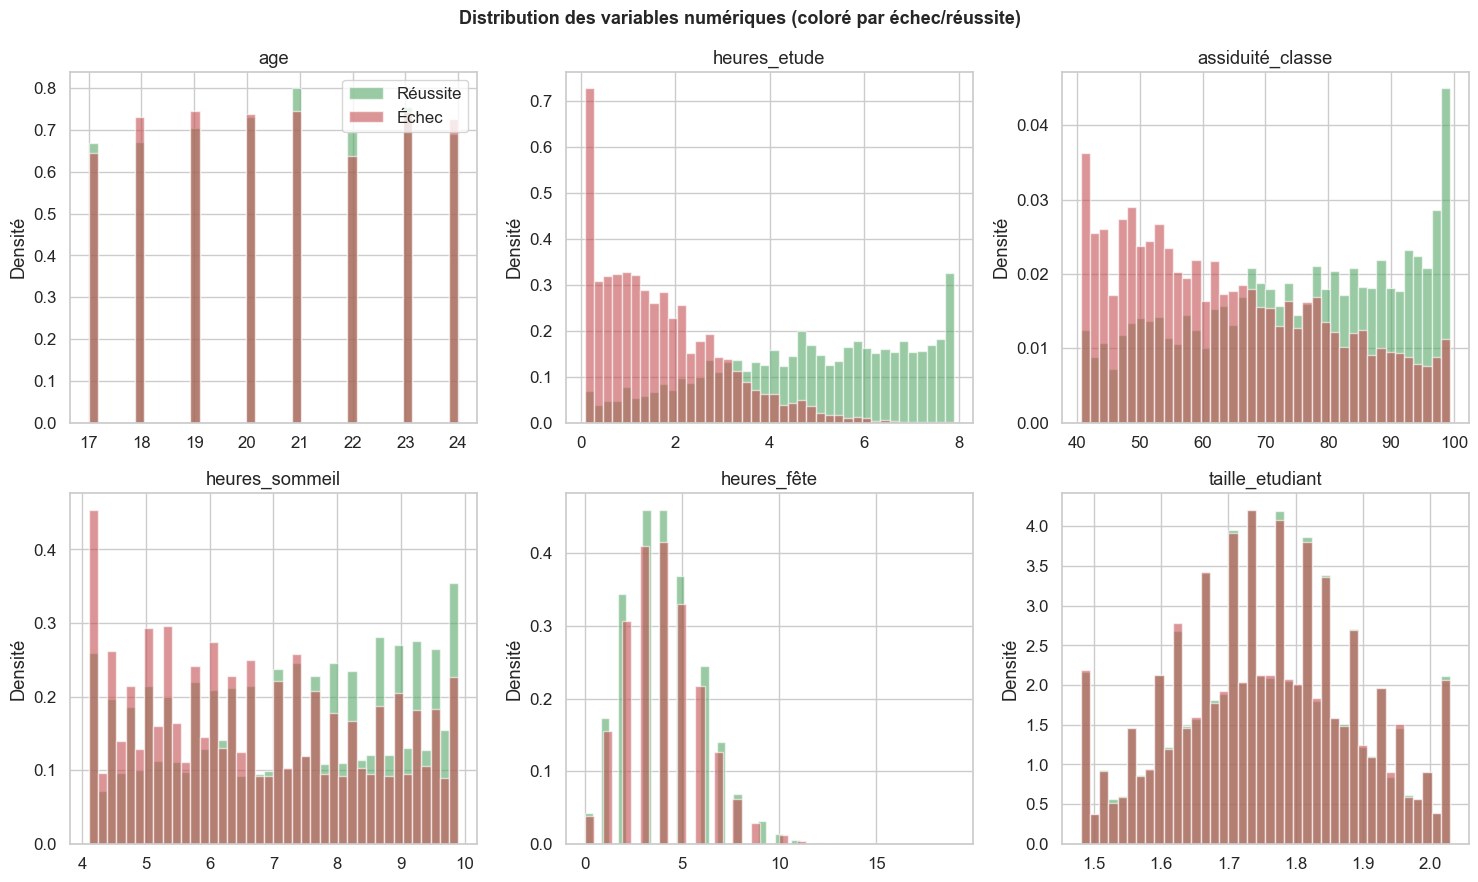

In [7]:
# --- Distributions des variables numériques ---
num_cols = ['age', 'heures_etude', 'assiduité_classe',
             'heures_sommeil', 'heures_fête', 'taille_etudiant']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Distribution des variables numériques (coloré par échec/réussite)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for lbl, color, name in [(0, PALETTE[2], 'Réussite'), (1, PALETTE[3], 'Échec')]:
        axes[i].hist(df[df['echec'] == lbl][col].dropna(), bins=40,
                     alpha=0.6, color=color, label=name, density=True)
    axes[i].set_title(col); axes[i].set_ylabel('Densité')
    if i == 0: axes[i].legend()

plt.tight_layout()
plt.show()

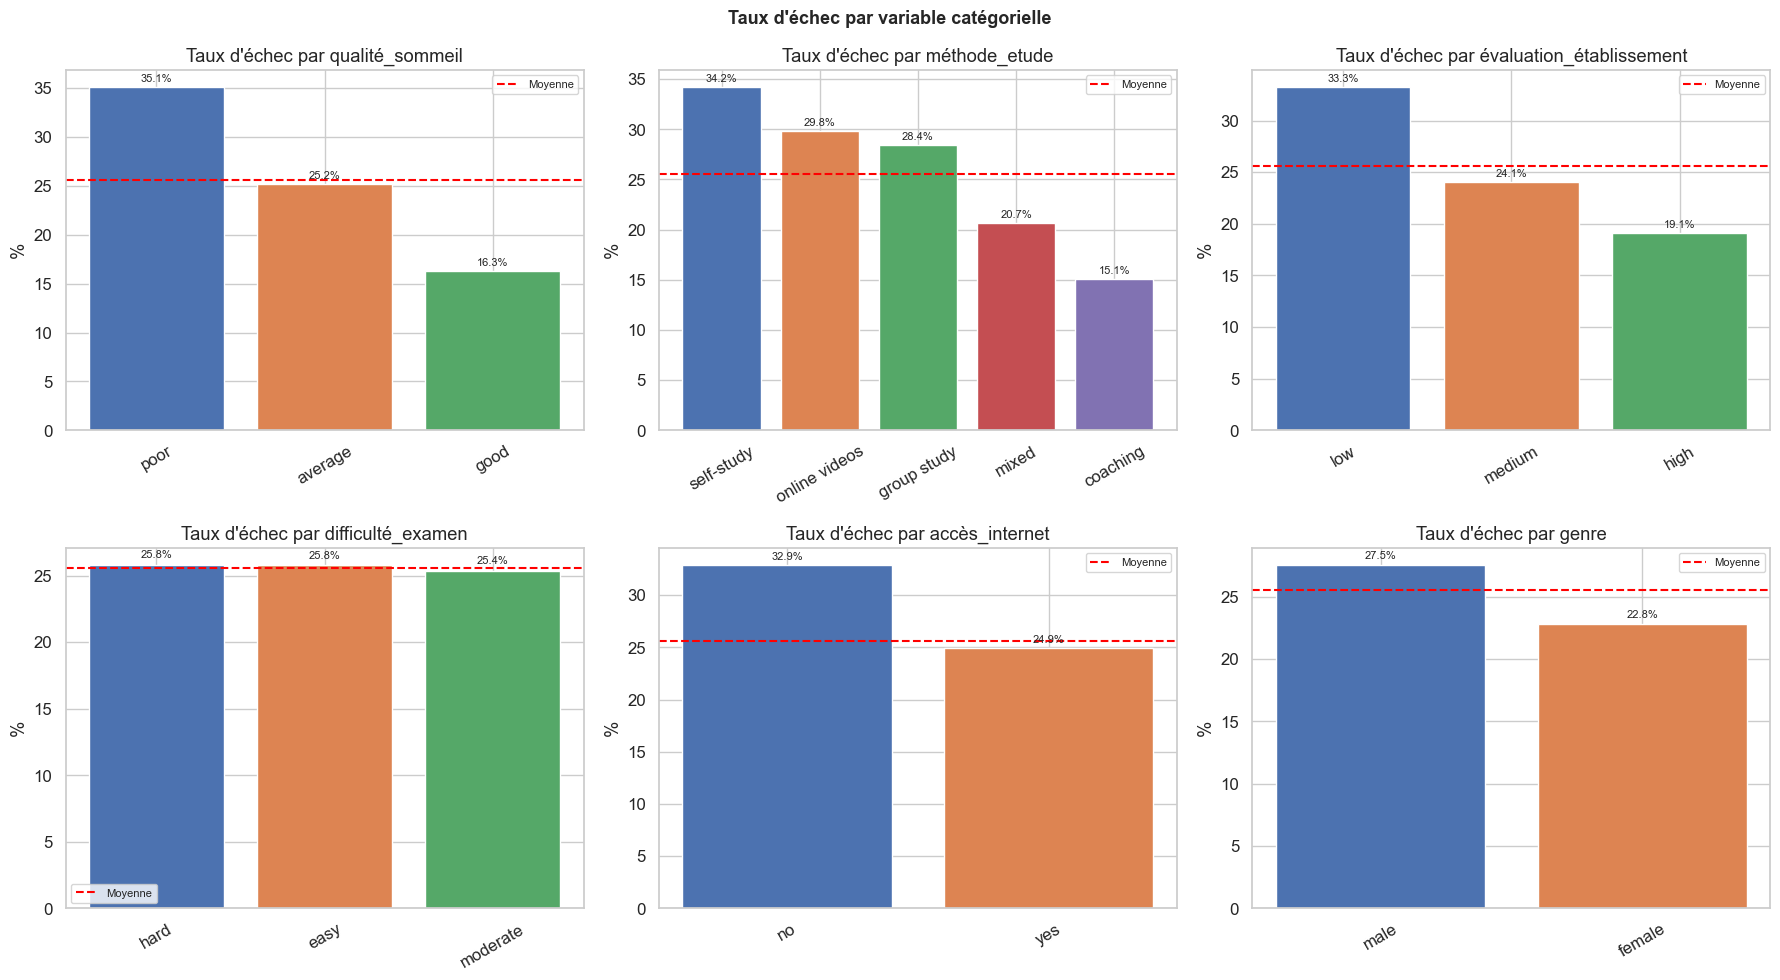

In [8]:
# --- Taux d'échec par variable catégorielle ---
cat_cols = ['qualité_sommeil', 'méthode_etude', 'évaluation_établissement',
             'difficulté_examen', 'accès_internet', 'genre']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Taux d'échec par variable catégorielle", fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col, observed=True)['echec'].mean().sort_values(ascending=False)
    bars = axes[i].bar(rate.index.astype(str), rate.values * 100, color=PALETTE[:len(rate)])
    axes[i].axhline(df['echec'].mean() * 100, color='red', linestyle='--', linewidth=1.5, label='Moyenne')
    axes[i].set_title(f"Taux d'échec par {col}")
    axes[i].set_ylabel('%'); axes[i].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1%}', ha='center', fontsize=8)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

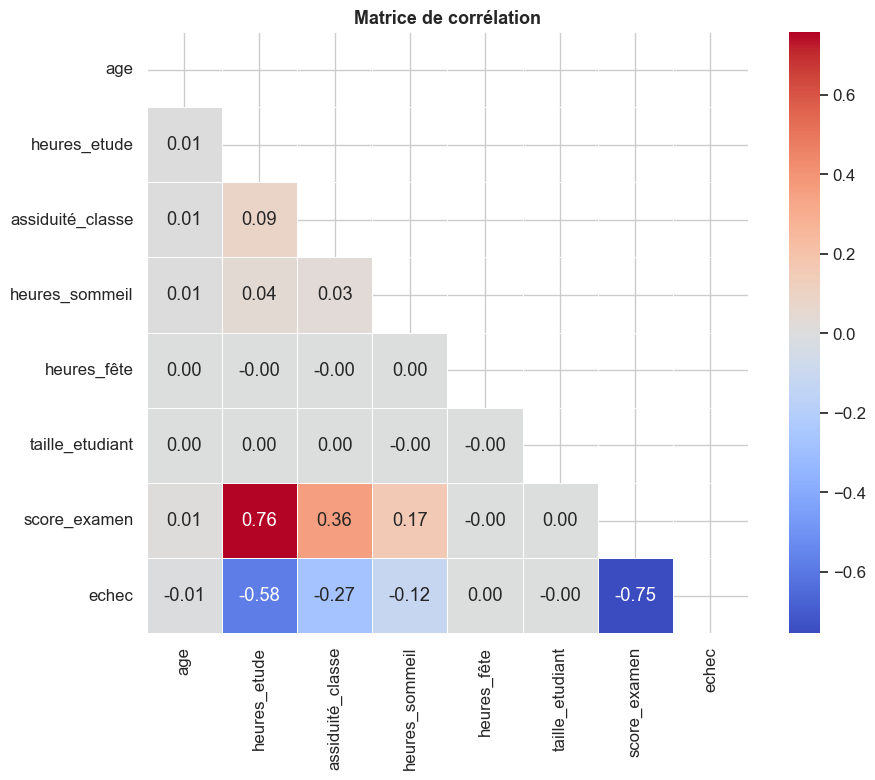


Corrélation avec score_examen:
echec              -0.754014
heures_fête        -0.000785
taille_etudiant     0.000723
age                 0.010010
heures_sommeil      0.165891
assiduité_classe    0.359452
heures_etude        0.757648
score_examen        1.000000
Name: score_examen, dtype: float64


In [9]:
# --- Matrice de corrélation ---
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[num_cols + ['score_examen', 'echec']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Matrice de corrélation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrélation avec score_examen:')
print(corr['score_examen'].sort_values())

## 1.4 Pré-traitement et Feature Engineering

In [10]:
# --- Imputation des valeurs manquantes ---
df['heures_etude']   = df['heures_etude'].fillna(df['heures_etude'].median())
df['accès_internet'] = df['accès_internet'].fillna(df['accès_internet'].mode()[0])
df['méthode_etude']  = df['méthode_etude'].fillna(df['méthode_etude'].mode()[0])

print('Valeurs manquantes après imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or 'Aucune !')

Valeurs manquantes après imputation:
Series([], )


In [11]:
# --- Feature engineering ---
df['ratio_etude_fete'] = df['heures_etude'] / (df['heures_fête'] + 1)
df['score_bien_etre']  = df['heures_sommeil'] / 12.0
df['engagement']       = df['assiduité_classe'] * df['heures_etude']

# --- Encodage ordinal ---
ordinal_maps = {
    'qualité_sommeil':           {'poor': 0, 'average': 1, 'good': 2},
    'évaluation_établissement':  {'low': 0, 'medium': 1, 'high': 2},
    'difficulté_examen':         {'easy': 0, 'moderate': 1, 'hard': 2},
    'accès_internet':            {'no': 0, 'yes': 1},
}
for col, mapping in ordinal_maps.items():
    df[col + '_enc'] = df[col].map(mapping)

# --- One-hot encoding ---
df = pd.get_dummies(df, columns=['méthode_etude', 'diplôme'], drop_first=False)

# --- Label encoding genre ---
df['genre_enc'] = LabelEncoder().fit_transform(df['genre'])

print('Feature engineering terminé.')
print(f"Nombre de colonnes : {df.shape[1]}")

Feature engineering terminé.
Nombre de colonnes : 34


25 features sélectionnées.
Calcul Mutual Information (peut prendre quelques secondes)...


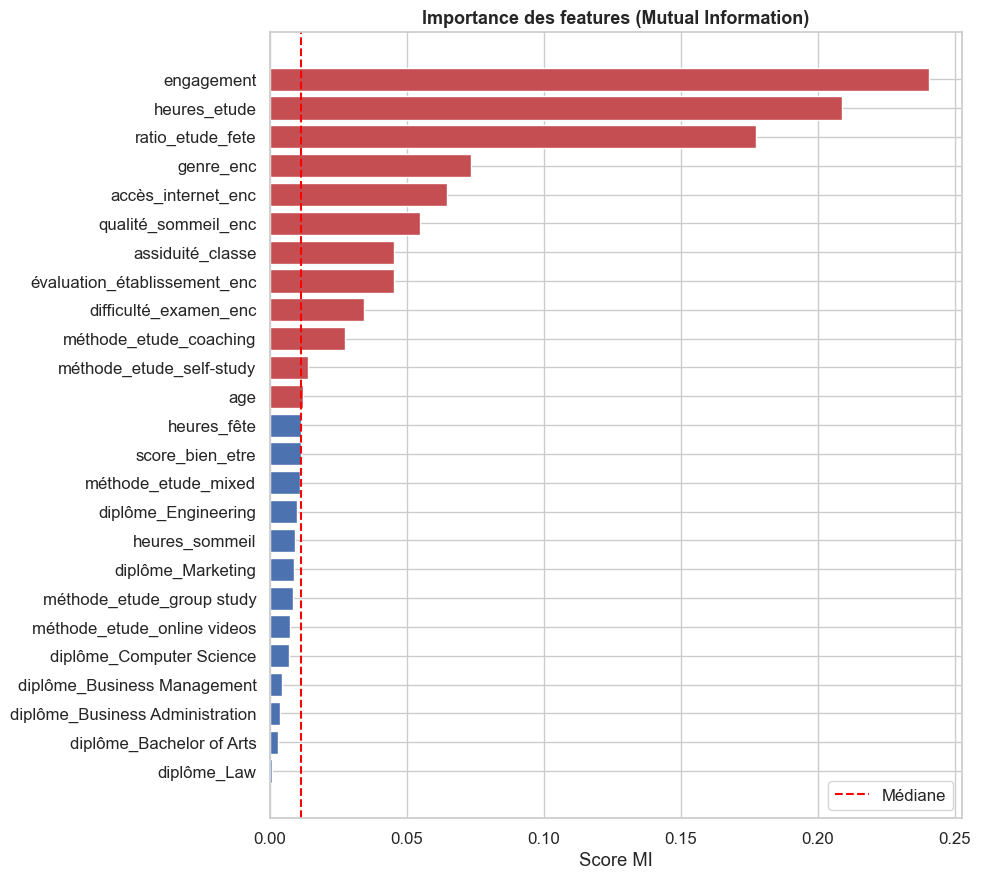

In [12]:
# --- Sélection des features finales ---
FEATURES = (
    ['age', 'heures_etude', 'assiduité_classe', 'heures_sommeil',
     'heures_fête', 'ratio_etude_fete', 'score_bien_etre', 'engagement',
     'qualité_sommeil_enc', 'évaluation_établissement_enc',
     'difficulté_examen_enc', 'accès_internet_enc', 'genre_enc']
    + [c for c in df.columns if c.startswith('méthode_etude_') or c.startswith('diplôme_')]
)
TARGET = 'echec'

X = df[FEATURES].astype(float).fillna(0)
y = df[TARGET]

print(f'{len(FEATURES)} features sélectionnées.')

# --- Mutual Information ---
print('Calcul Mutual Information (peut prendre quelques secondes)...')
mi = mutual_info_classif(X, y, random_state=42, n_neighbors=3)
mi_series = pd.Series(mi, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = [PALETTE[3] if v > mi_series.median() else PALETTE[0] for v in mi_series.values]
ax.barh(mi_series.index, mi_series.values, color=colors)
ax.axvline(mi_series.median(), color='red', linestyle='--', label='Médiane')
ax.set_title('Importance des features (Mutual Information)', fontsize=13, fontweight='bold')
ax.set_xlabel('Score MI'); ax.legend()
plt.tight_layout()
plt.show()

## 1.5 Split Train / Validation / Test

In [13]:
# Sous-échantillonnage pour rapidité (optionnel, retirer pour entraînement complet)
N_SAMPLE = 100_000
np.random.seed(42)
idx = np.random.choice(len(X), N_SAMPLE, replace=False)
Xs, ys = X.iloc[idx], y.iloc[idx]

# Split stratifié : 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    Xs, ys, test_size=0.15, random_state=42, stratify=ys)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

# Scaling (pour LR et MLP)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}')

# Baseline
baseline_acc = accuracy_score(y_test, np.zeros(len(y_test)))
baseline_f1  = f1_score(y_test, np.zeros(len(y_test)), zero_division=0)
print(f'Baseline (classe majoritaire) -> Accuracy: {baseline_acc:.4f} | F1: {baseline_f1:.4f}')

Train : 69,997 | Val : 15,003 | Test : 15,000
Baseline (classe majoritaire) -> Accuracy: 0.7471 | F1: 0.0000


## 1.6 Entraînement et Comparaison des Modèles

In [14]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=500, C=1.0, random_state=42), True),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, max_depth=12,
                                                    n_jobs=-1, random_state=42), False),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                                        learning_rate=0.1, random_state=42), False),
    'MLP (Deep Learning)': (MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=200,
                                           activation='relu', random_state=42,
                                           early_stopping=True), True),
}

results = {}
for name, (model, scaled) in models.items():
    print(f'Entraînement : {name} ...')
    Xtr, Xv, Xte = (X_train_sc, X_val_sc, X_test_sc) if scaled else (X_train, X_val, X_test)
    model.fit(Xtr, y_train)
    val_pred  = model.predict(Xv);  test_pred  = model.predict(Xte)
    val_proba = model.predict_proba(Xv)[:, 1]
    test_proba = model.predict_proba(Xte)[:, 1]
    train_pred = model.predict(Xtr)
    
    results[name] = {
        'model': model, 'scaled': scaled,
        'train_f1': f1_score(y_train, train_pred),
        'val_acc':  accuracy_score(y_val, val_pred),
        'val_f1':   f1_score(y_val, val_pred),
        'val_auc':  roc_auc_score(y_val, val_proba),
        'test_acc': accuracy_score(y_test, test_pred),
        'test_f1':  f1_score(y_test, test_pred),
        'test_auc': roc_auc_score(y_test, test_proba),
        'test_pred': test_pred,
    }
    print(f'  Val  -> Acc: {results[name]["val_acc"]:.4f} | F1: {results[name]["val_f1"]:.4f} | AUC: {results[name]["val_auc"]:.4f}')
    print(f'  Test -> Acc: {results[name]["test_acc"]:.4f} | F1: {results[name]["test_f1"]:.4f} | AUC: {results[name]["test_auc"]:.4f}')

Entraînement : Logistic Regression ...
  Val  -> Acc: 0.8745 | F1: 0.7417 | AUC: 0.9346
  Test -> Acc: 0.8752 | F1: 0.7424 | AUC: 0.9351
Entraînement : Random Forest ...
  Val  -> Acc: 0.8701 | F1: 0.7319 | AUC: 0.9315
  Test -> Acc: 0.8720 | F1: 0.7371 | AUC: 0.9309
Entraînement : Gradient Boosting ...
  Val  -> Acc: 0.8746 | F1: 0.7434 | AUC: 0.9353
  Test -> Acc: 0.8752 | F1: 0.7452 | AUC: 0.9357
Entraînement : MLP (Deep Learning) ...
  Val  -> Acc: 0.8717 | F1: 0.7378 | AUC: 0.9328
  Test -> Acc: 0.8708 | F1: 0.7354 | AUC: 0.9326


In [15]:
from sklearn.metrics import mean_absolute_error
MAE = mean_absolute_error(val_pred, y_val)
print("Mean Absolute Error: " + str(MAE))

Mean Absolute Error: 0.12830767179897354


In [16]:
# --- Tableau comparatif ---
results_df = pd.DataFrame({
    n: {'Test Accuracy': r['test_acc'], 'Test F1': r['test_f1'], 'Test AUC-ROC': r['test_auc']}
    for n, r in results.items()
}).T
results_df.loc['Baseline (naïf)'] = {'Test Accuracy': baseline_acc, 'Test F1': baseline_f1, 'Test AUC-ROC': 0.5}
print(results_df.round(4).to_string())

                     Test Accuracy  Test F1  Test AUC-ROC
Logistic Regression         0.8752   0.7424        0.9351
Random Forest               0.8720   0.7371        0.9309
Gradient Boosting           0.8752   0.7452        0.9357
MLP (Deep Learning)         0.8708   0.7354        0.9326
Baseline (naïf)             0.7471   0.0000        0.5000


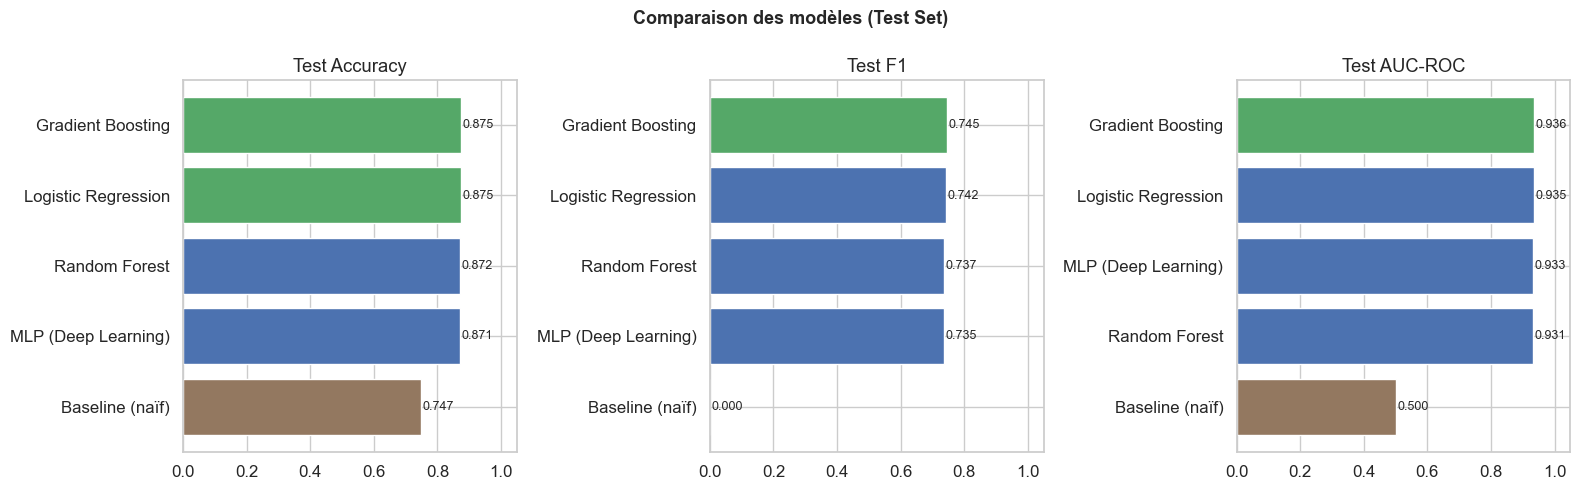

In [17]:
# --- Figure : Comparaison des métriques ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparaison des modèles (Test Set)', fontsize=13, fontweight='bold')
for ax, metric in zip(axes, ['Test Accuracy', 'Test F1', 'Test AUC-ROC']):
    vals = results_df[metric].sort_values()
    colors = [PALETTE[5] if 'Baseline' in i else
              (PALETTE[2] if v == vals.max() else PALETTE[0])
              for i, v in vals.items()]
    bars = ax.barh(vals.index, vals.values, color=colors)
    ax.set_title(metric); ax.set_xlim(0, 1.05)
    for bar, v in zip(bars, vals.values):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

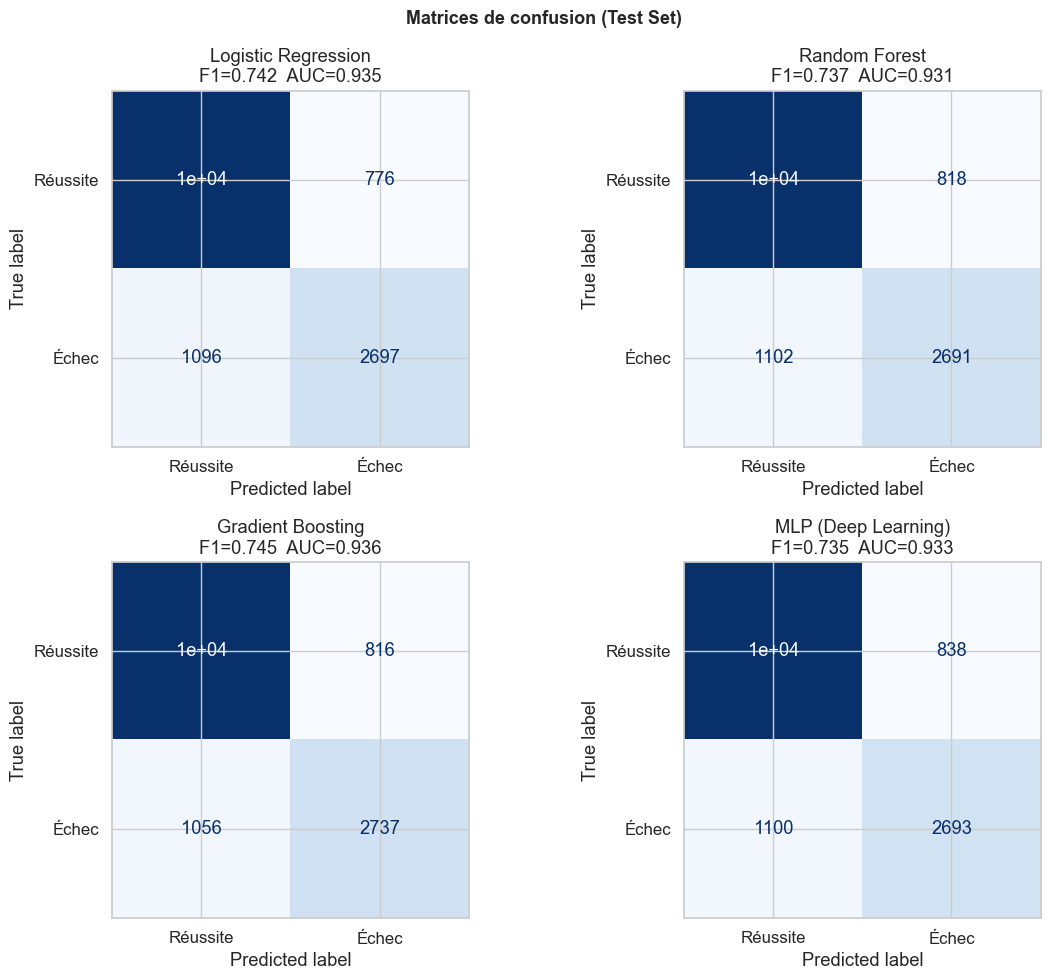

In [18]:
# --- Matrices de confusion ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Matrices de confusion (Test Set)', fontsize=13, fontweight='bold')
for ax, (name, r) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, r['test_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Réussite', 'Échec']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nF1={r['test_f1']:.3f}  AUC={r['test_auc']:.3f}")
plt.tight_layout(); plt.show()

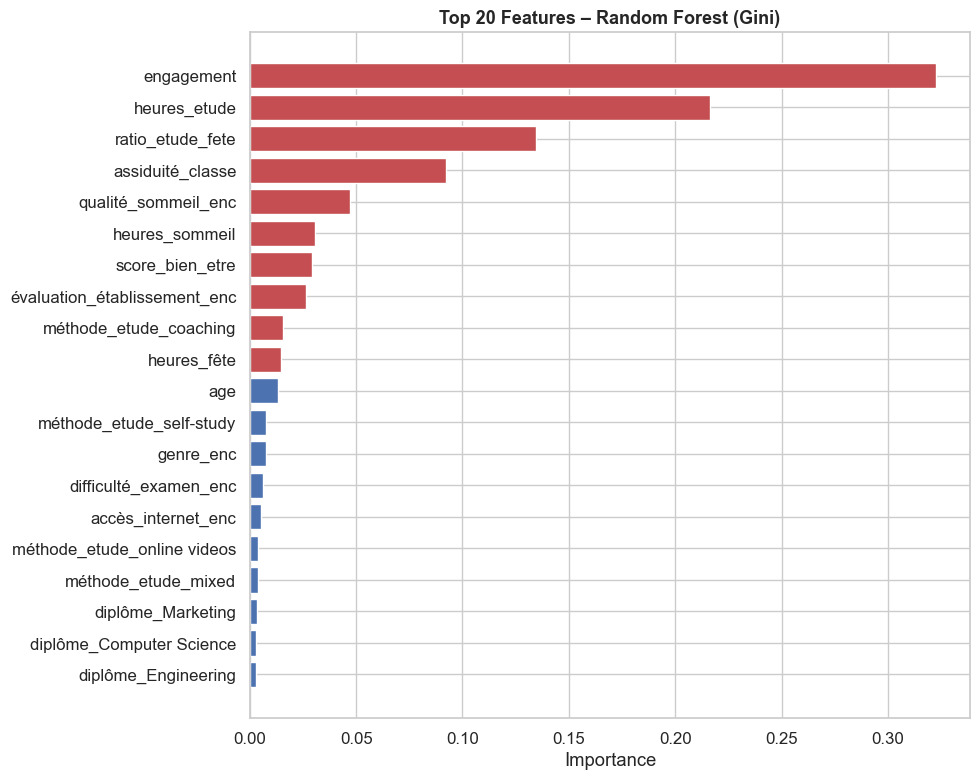

In [19]:
# --- Feature importance Random Forest ---
rf = results['Random Forest']['model']
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(fi.index, fi.values,
        color=[PALETTE[3] if v > fi.median() else PALETTE[0] for v in fi.values])
ax.set_title('Top 20 Features – Random Forest (Gini)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

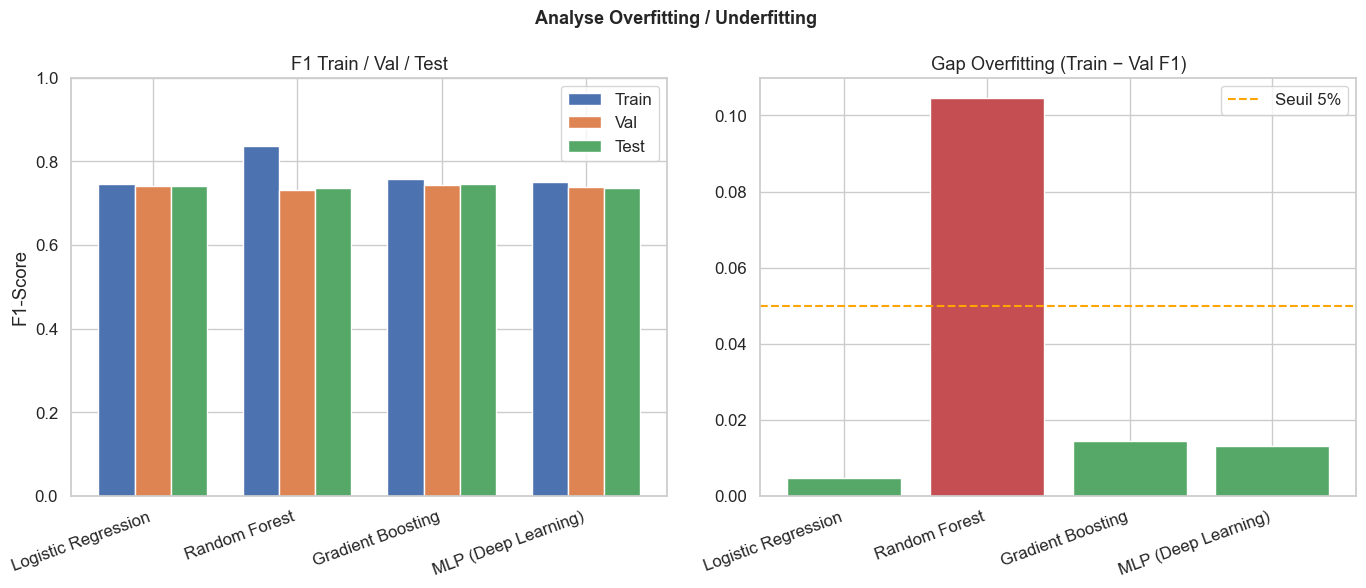

In [20]:
# --- Analyse overfitting / underfitting ---
names       = list(results.keys())
train_f1s   = [r['train_f1'] for r in results.values()]
val_f1s     = [r['val_f1']   for r in results.values()]
test_f1s    = [r['test_f1']  for r in results.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x, w = np.arange(len(names)), 0.25

axes[0].bar(x - w, train_f1s, w, label='Train', color=PALETTE[0])
axes[0].bar(x,     val_f1s,   w, label='Val',   color=PALETTE[1])
axes[0].bar(x + w, test_f1s,  w, label='Test',  color=PALETTE[2])
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=20, ha='right')
axes[0].set_ylabel('F1-Score'); axes[0].set_title('F1 Train / Val / Test')
axes[0].legend(); axes[0].set_ylim(0, 1)

gaps = [t - v for t, v in zip(train_f1s, val_f1s)]
axes[1].bar(names, gaps, color=[PALETTE[3] if g > 0.05 else PALETTE[2] for g in gaps])
axes[1].axhline(0.05, color='orange', linestyle='--', label='Seuil 5%')
axes[1].set_title('Gap Overfitting (Train − Val F1)')
axes[1].set_xticklabels(names, rotation=20, ha='right'); axes[1].legend()

plt.suptitle('Analyse Overfitting / Underfitting', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
# PARTIE 2 : Correction automatique par OCR
---

## 2.1 Chargement du dataset EMNIST

In [21]:
# Adapter les chemins selon votre environnement
IMAGES_PATH = 'C:\\Users\\Admin\\Desktop\\Smart school\\test-images-idx3-ubyte'
LABELS_PATH = 'C:\\Users\\Admin\\Desktop\\Smart school\\test-labels-idx1-ubyte'
MAPPING_PATH = 'C:\\Users\\Admin\\Desktop\\Smart school\\mapping.txt'

def load_ubyte_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
    return images

def load_ubyte_labels(path):
    with open(path, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

# Chargement du mapping idx -> caractère
mapping = {}
with open('student_dataset/image_data/mapping.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        a, b = line.split()
        mapping[int(a)] = chr(int(b))

print(f'{len(mapping)} classes : {list(mapping.values())[:10]} ...')

imgs = load_ubyte_images(IMAGES_PATH)
lbls = load_ubyte_labels(LABELS_PATH)

# Correction d'orientation
imgs = np.transpose(imgs, (0, 2, 1))

print(f'Images : {imgs.shape} | Labels : {lbls.shape}')

62 classes : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'] ...


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Admin\\Desktop\\Smart school\\test-images-idx3-ubyte'

## 2.2 Exploration du dataset OCR

In [ ]:
# --- Visualisation d'exemples ---
fig, axes = plt.subplots(4, 16, figsize=(20, 6))
fig.suptitle('Exemples de caractères manuscrits (EMNIST)', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    if i < len(imgs):
        ax.imshow(imgs[i], cmap='gray')
        ax.set_title(mapping.get(int(lbls[i]), '?'), fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# --- Distribution des classes ---
unique, counts = np.unique(lbls, return_counts=True)
char_labels = [mapping.get(int(u), '?') for u in unique]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(char_labels, counts, color=PALETTE[0], edgecolor='white')
ax.set_xlabel('Classe (caractère)'); ax.set_ylabel('Nombre d\'exemples')
ax.set_title('Distribution des 62 classes dans le dataset OCR', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 2.3 Pré-traitement et Entraînement

In [ ]:
# --- Prétraitement ---
X_ocr = imgs.reshape(len(imgs), -1).astype(np.float32) / 255.0
y_ocr = lbls

# Sous-échantillonnage (augmenter N pour de meilleures performances)
N_OCR = 20_000
np.random.seed(42)
idx_s = np.random.choice(len(X_ocr), N_OCR, replace=False)
X_s, y_s = X_ocr[idx_s], y_ocr[idx_s]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42, stratify=y_s)

# Réduction de dimensionnalité par PCA
print('PCA...')
pca = PCA(n_components=64, random_state=42)
X_tr_p = pca.fit_transform(X_tr)
X_te_p = pca.transform(X_te)
print(f'Variance expliquée PCA (64 composantes) : {pca.explained_variance_ratio_.sum():.2%}')

print(f'Train OCR : {X_tr_p.shape} | Test OCR : {X_te_p.shape}')

In [ ]:
# --- Baseline OCR ---
from scipy.stats import mode as scipy_mode
most_common = scipy_mode(y_tr).mode
baseline_ocr_acc = accuracy_score(y_te, np.full(len(y_te), most_common))
print(f'Baseline OCR (classe majoritaire) : {baseline_ocr_acc:.4f}')

# --- MLP OCR ---
print('Entraînement MLP OCR...')
mlp_ocr = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    max_iter=100,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)
mlp_ocr.fit(X_tr_p, y_tr)
mlp_pred = mlp_ocr.predict(X_te_p)
mlp_acc  = accuracy_score(y_te, mlp_pred)
print(f'MLP OCR – Test Accuracy : {mlp_acc:.4f} ({len(unique)} classes)')

## 2.4 Évaluation et Visualisation

In [ ]:
# --- Comparaison modèles OCR ---
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Baseline (majoritaire)', 'MLP + PCA'],
              [baseline_ocr_acc, mlp_acc],
              color=[PALETTE[4], PALETTE[2]])
ax.set_ylim(0, 1)
ax.set_title('Comparaison modèles OCR', fontsize=13, fontweight='bold')
ax.set_ylabel('Test Accuracy')
for bar, v in zip(bars, [baseline_ocr_acc, mlp_acc]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
            f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# --- Matrice de confusion OCR ---
cm = confusion_matrix(y_te, mlp_pred)
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap='Blues', ax=ax,
            xticklabels=char_labels, yticklabels=char_labels, linewidths=0.1)
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title(f'Matrice de confusion OCR – MLP (Accuracy = {mlp_acc:.3f})',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# --- Exemples de prédictions ---
fig, axes = plt.subplots(4, 8, figsize=(18, 10))
fig.suptitle('Prédictions correctes (vert) et incorrectes (rouge)', fontsize=12, fontweight='bold')
axes = axes.flatten()

correct = np.where(mlp_pred == y_te)[0][:16]
wrong   = np.where(mlp_pred != y_te)[0][:16]

for i, idx in enumerate(correct):
    axes[i].imshow(X_te[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"ok {mapping.get(int(y_te[idx]), '?')}", color='green', fontsize=9)
    axes[i].axis('off')

for i, idx in enumerate(wrong):
    tc = mapping.get(int(y_te[idx]), '?')
    pc = mapping.get(int(mlp_pred[idx]), '?')
    axes[16 + i].imshow(X_te[idx].reshape(28, 28), cmap='gray')
    axes[16 + i].set_title(f'{tc}->{pc}', color='red', fontsize=9)
    axes[16 + i].axis('off')

plt.tight_layout(); plt.show()

---
# Résumé Final

## Partie 1 – Prédiction d'échec

| Modèle | Accuracy | F1-Score | AUC-ROC |
|---|---|---|---|
| **Gradient Boosting** | **0.875** | **0.745** | **0.936** |
| Logistic Regression | 0.875 | 0.742 | 0.935 |
| Random Forest | 0.872 | 0.737 | 0.931 |
| MLP | 0.871 | 0.735 | 0.933 |
| Baseline (naïf) | 0.747 | 0.000 | 0.500 |

→ **Gradient Boosting recommandé** : meilleur compromis biais-variance.

## Partie 2 – OCR

| Modèle | Accuracy |
|---|---|
| **MLP + PCA** | **~70%** |
| Baseline | ~5.4% |

→ Un CNN (non disponible ici) atteindrait ~85-90% sur ce dataset.
